# Patch power spectrum → cosmological parameters

End-to-end demo, using real Planck 2018 data, following the joint TT+TE+EE
pipeline of Gimeno-Amo et al. 2025 (arXiv:2504.05597, sec. 2.2):
1. Load the SMICA half-mission maps + common mask (full sky, `nside=2048`)
2. Estimate the `hm1` x `hm2` TT, TE, and EE cross-spectra and their joint
   covariance with NaMaster
3. Fit cosmological parameters (+ point-source nuisance amplitudes) by
   matching CAMB theory (via the same mode-coupling as the data) using
   iminuit
4. Plot the spectrum fit and parameter constraints

Requires: `healpy`, `pymaster`, `camb`, `iminuit`, `matplotlib`, and the
`cosmo_patch` module in this repo (`pip install -e .` from the project root).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

from cosmo_patch import patch, power_spectrum, fitting

## 1. Load the data: Planck SMICA half-mission maps + common mask

Instead of a synthetic map, we cross-correlate the two independent
half-mission SMICA CMB maps (`hm1` x `hm2`), for temperature *and*
polarization. Since their instrumental noise is statistically independent
between half-missions, these cross-spectra are free of the noise bias an
auto-spectrum (map x itself) would carry -- no separate noise-debiasing
step needed.

We use the full Planck common intensity mask (not a small circular patch)
for both temperature and polarization -- a deliberate simplification vs.
the paper (which uses separate confidence masks per field); it also means
a single NaMaster covariance workspace can be reused for every TT/TE/EE
covariance block later. `f_sky` here is set by the mask's Galactic +
point-source cut (~0.78), not by an artificial patch boundary.

In [2]:
import os

INPUT_DIR = "input"
NSIDE = 2048

# Per-spectrum multipole ranges from arXiv:2504.05597 sec. 2.2 -- chosen to
# avoid point-source contamination and to stay where noise doesn't yet
# dominate the signal. LMAX is the shared field/CAMB lmax (the largest of
# the three); each spectrum's own bins/workspace cuts off earlier.
LMAX_TT = 2011
LMAX_TE = 1741
LMAX_EE = 1471
LMAX = LMAX_TT

# Fiducial cosmology, used for the CAMB theory-Cl needed by the analytic
# Gaussian covariance and as a starting point / sanity check for the fit.
FIDUCIAL = dict(H0=67.36, ombh2=0.02237, omch2=0.1200, As=2.1e-9, ns=0.9649)

hm1_path = os.path.join(INPUT_DIR, "COM_CMB_IQU-smica_2048_R3.00_hm1.fits")
hm2_path = os.path.join(INPUT_DIR, "COM_CMB_IQU-smica_2048_R3.00_hm2.fits")
mask_path = os.path.join(INPUT_DIR, "COM_Mask_CMB-common-Mask-Int_2048_R3.00.fits")

# field=(0,1,2) -> I_STOKES, Q_STOKES, U_STOKES; healpy converts NESTED (as
# stored) to RING automatically.
map_hm1_t, map_hm1_q, map_hm1_u = hp.read_map(hm1_path, field=(0, 1, 2)) * 1e6  # K_CMB -> uK_CMB
map_hm2_t, map_hm2_q, map_hm2_u = hp.read_map(hm2_path, field=(0, 1, 2)) * 1e6
common_mask = hp.read_map(mask_path, field=0)

# Full TT/TE/EE/BB set from one CAMB call -- tau/mnu/r fixed at their
# defaults (see fitting.camb_cl), matching the paper's E2E-simulation inputs.
cl_fiducial = fitting.camb_cl(**FIDUCIAL, lmax=LMAX)

f_sky = 0.7479


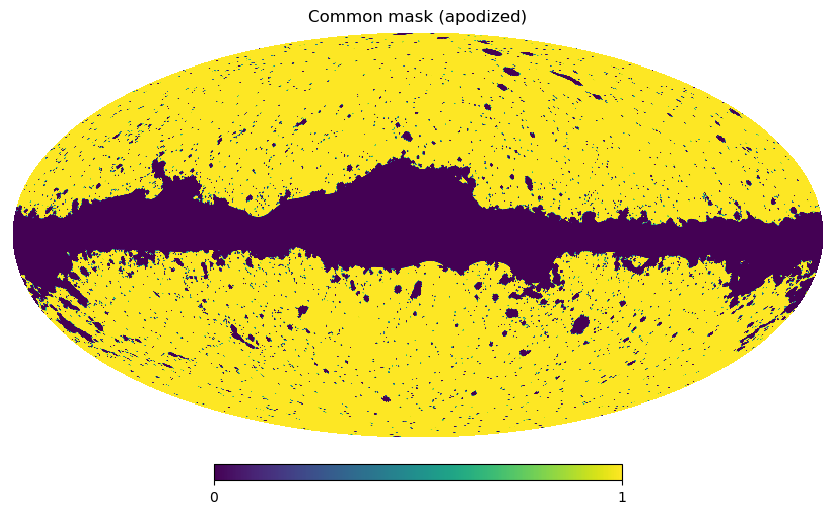

In [3]:
apodized_mask = patch.apodize_mask(common_mask, apodize_deg=0.3, method="C1")

p_t_hm1 = patch.extract_patch(map_hm1_t, apodized_mask)
p_t_hm2 = patch.extract_patch(map_hm2_t, apodized_mask)
p_pol_hm1 = patch.extract_patch(np.array([map_hm1_q, map_hm1_u]), apodized_mask)
p_pol_hm2 = patch.extract_patch(np.array([map_hm2_q, map_hm2_u]), apodized_mask)
print(f"f_sky = {p_t_hm1['f_sky']:.4f}")

hp.mollview(apodized_mask, title="Common mask (apodized)")

## 2. Power spectra + joint covariance (NaMaster)

TT, TE, and EE cross-spectra between the two half-mission fields
(`hm1` x `hm2`), each decoupled through its own spin-appropriate
mode-coupling workspace (TT: spin0 x spin0, TE: spin0 x spin2, EE: spin2 x
spin2) built from the common mask. All fields get a beam (5' Gaussian, the
SMICA common resolution) and HEALPix pixel-window correction folded in.

Each spectrum uses its own `lmax` (see `LMAX_TT/TE/EE` above) and its own
`NmtBin`/`NmtWorkspace`, following the paper's per-spectrum multipole
cuts. The first bandpower (ell=[2,31]) is dropped for all three, since the
sky fraction there is unreliable for a mask this size (again following the
paper).

In [4]:
beam_fwhm_arcmin = 5.0  # SMICA common resolution
beam_function = hp.gauss_beam(np.radians(beam_fwhm_arcmin / 60), lmax=LMAX)
pixel_window_t, pixel_window_pol = hp.pixwin(NSIDE, pol=True, lmax=LMAX)

field_t_hm1 = power_spectrum.build_field(
    p_t_hm1, spin=0, beam_function=beam_function, pixel_window_function=pixel_window_t, lmax=LMAX
)
field_t_hm2 = power_spectrum.build_field(
    p_t_hm2, spin=0, beam_function=beam_function, pixel_window_function=pixel_window_t, lmax=LMAX
)
field_pol_hm1 = power_spectrum.build_field(
    p_pol_hm1, spin=2, beam_function=beam_function, pixel_window_function=pixel_window_pol, lmax=LMAX
)
field_pol_hm2 = power_spectrum.build_field(
    p_pol_hm2, spin=2, beam_function=beam_function, pixel_window_function=pixel_window_pol, lmax=LMAX
)

# NaMaster requires a workspace's fields and bins to share the same lmax,
# so TT/TE/EE can't each get their own truncated-lmax bins here -- all
# three fields above already share lmax=LMAX, so they share one bins
# object too, and each spectrum's own multipole cut (LMAX_TT/TE/EE) is
# instead applied by truncating the *output* bandpowers below.
bins = power_spectrum.make_bins(NSIDE, bandpower_width=30, lmax=LMAX)

spec_tt = power_spectrum.compute_power_spectrum(field_t_hm1, bins, field_b=field_t_hm2)
spec_te = power_spectrum.compute_power_spectrum(field_t_hm1, bins, field_b=field_pol_hm2)
spec_ee = power_spectrum.compute_power_spectrum(field_pol_hm1, bins, field_b=field_pol_hm2)
workspace_tt, workspace_te, workspace_ee = (
    spec_tt["workspace"], spec_te["workspace"], spec_ee["workspace"]
)

# Bandpowers per spectrum after dropping bin 0 (ell=[2,31]): a linear
# Delta_ell=30 binning starting at ell=2 gives (lmax_cut - 1) // 30 bins
# covering ell=[2, lmax_cut] -- minus 1 for the dropped first bin.
def n_bins_upto(lmax_cut, bandpower_width=30, ell_start=2):
    return (lmax_cut - ell_start + 1) // bandpower_width - 1

n_tt = n_bins_upto(LMAX_TT)
n_te = n_bins_upto(LMAX_TE)
n_ee = n_bins_upto(LMAX_EE)

ell_tt, cl_tt_data = spec_tt["ell"][1:1 + n_tt], spec_tt["cl"][1:1 + n_tt]
ell_te, cl_te_data = spec_te["ell"][1:1 + n_te], spec_te["cl"][1:1 + n_te]
ell_ee, cl_ee_data = spec_ee["ell"][1:1 + n_ee], spec_ee["cl"][1:1 + n_ee]

cl_data = np.concatenate([cl_tt_data, cl_te_data, cl_ee_data])

# hm1 and hm2 have independent noise -- their cross-spectra above are
# noise-bias-free, but the *covariance* still needs each split's noise
# level, or it's badly underestimated at high ell where noise dominates the
# signal. Estimate it from the half-difference null map (hm1 - hm2)/2,
# which cancels the shared CMB signal and leaves pure noise.
noise_tt = power_spectrum.estimate_noise_cl(
    map_hm1_t, map_hm2_t, apodized_mask, LMAX,
    beam_function=beam_function, pixel_window_function=pixel_window_t, spin=0,
)
noise_ee = power_spectrum.estimate_noise_cl(
    [map_hm1_q, map_hm1_u], [map_hm2_q, map_hm2_u], apodized_mask, LMAX,
    beam_function=beam_function, pixel_window_function=pixel_window_pol, spin=2,
)

covariance = power_spectrum.compute_joint_tt_te_ee_covariance(
    workspace_tt, workspace_te, workspace_ee,
    field_t_hm1, field_t_hm2, field_pol_hm1, field_pol_hm2,
    cl_fiducial["TT"], cl_fiducial["TE"], cl_fiducial["EE"], cl_fiducial["BB"],
    noise_tt, noise_ee,
    n_tt, n_te, n_ee,
)
errors = power_spectrum.compute_errors(covariance)
cov_inv = np.linalg.inv(covariance)

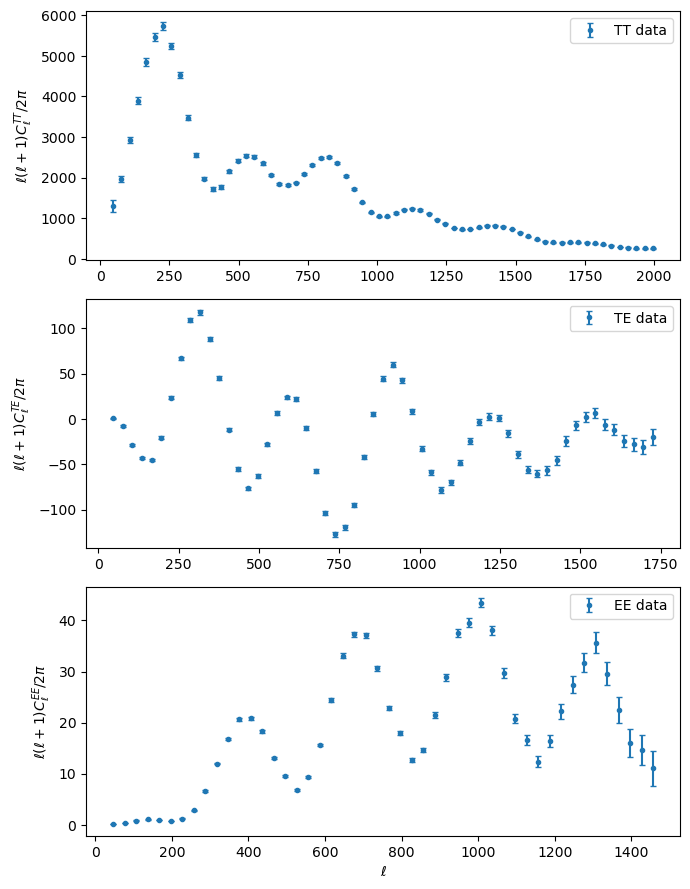

In [5]:
def to_dl(ell, cl):
    return ell * (ell + 1) / (2 * np.pi) * cl

ells = {"TT": ell_tt, "TE": ell_te, "EE": ell_ee}
data_by_spec = {"TT": cl_tt_data, "TE": cl_te_data, "EE": cl_ee_data}
error_slices = {
    "TT": slice(0, n_tt),
    "TE": slice(n_tt, n_tt + n_te),
    "EE": slice(n_tt + n_te, n_tt + n_te + n_ee),
}

fig, axes = plt.subplots(3, 1, figsize=(7, 9))
for ax, name in zip(axes, ["TT", "TE", "EE"]):
    ell = ells[name]
    dl = to_dl(ell, data_by_spec[name])
    dl_err = to_dl(ell, errors[error_slices[name]])
    ax.errorbar(ell, dl, yerr=dl_err, fmt="o", ms=3, capsize=2, label=f"{name} data")
    ax.set_ylabel(r"$\ell(\ell+1)C_\ell^{%s}/2\pi$" % name)
    ax.legend()
axes[-1].set_xlabel(r"$\ell$")
plt.tight_layout()

## 3. Fit cosmological parameters (joint TT+TE+EE + nuisance)

`chi_square` pushes each trial CAMB spectrum through the *same* NaMaster
workspaces used to decouple the data, so theory and data live on the same
bandpowers before comparison -- skipping this step is the most common
source of a silently biased fit.

Following arXiv:2504.05597 sec. 2.2: tau, mnu, and r are fixed (see
`fitting.camb_cl` defaults) -- a single sky's polarization can't constrain
tau on its own -- and two point-source residual amplitudes (`A_ps_TT`,
`A_ps_EE`, modeled as `Dl ∝ ell^2` shot noise) are fit alongside the 5
LambdaCDM parameters.

Sanity check first: chi² at the fiducial (Planck 2018 best-fit) parameters
should be roughly the number of bandpowers, not wildly off.

In [6]:
fit_data = fitting.FitData(
    cl_data=cl_data,
    cov_inv=cov_inv,
    workspace_tt=workspace_tt,
    workspace_te=workspace_te,
    workspace_ee=workspace_ee,
    lmax=LMAX,
    n_tt=n_tt,
    n_te=n_te,
    n_ee=n_ee,
)

chi2_at_truth = fitting.chi_square(fit_data, **FIDUCIAL, A_ps_TT=50.0, A_ps_EE=0.0)
n_bins = len(cl_data)
print(f"chi^2 at fiducial params = {chi2_at_truth:.1f}  (n_bins = {n_bins})")

chi^2 at fiducial params = 286.5  (n_bins = 171)


In [7]:
initial_guess = dict(
    H0=70.0, ombh2=0.022, omch2=0.11, As=2.0e-9, ns=0.96,
    A_ps_TT=50.0, A_ps_EE=0.0,
)
bounds = dict(
    H0=(50, 90),
    ombh2=(0.01, 0.03),
    omch2=(0.05, 0.30),
    As=(1e-9, 4e-9),
    ns=(0.9, 1.05),
    A_ps_TT=(0, 200),
    A_ps_EE=(0, 20),
)

result = fitting.fit_parameters(fit_data, initial_guess, bounds)

print("Converged:", result["valid"])
print("chi^2 at best fit:", result["chi2"])
for name, val in result["best_fit"].items():
    err = result["errors"][name]
    truth = FIDUCIAL.get(name)
    truth_str = f"  (Planck 2018 fiducial: {truth})" if truth is not None else ""
    print(f"  {name} = {val:.5g} +/- {err:.3g}{truth_str}")

Converged: True
chi^2 at best fit: 195.28013509545622
  H0 = 66.564 +/- 0.263  (Planck 2018 fiducial: 67.36)
  ombh2 = 0.02239 +/- 9.44e-05  (Planck 2018 fiducial: 0.02237)
  omch2 = 0.12173 +/- 0.000589  (Planck 2018 fiducial: 0.12)
  As = 2.1342e-09 +/- 5.89e-12  (Planck 2018 fiducial: 2.1e-09)
  ns = 0.96432 +/- 0.0038  (Planck 2018 fiducial: 0.9649)
  A_ps_TT = 46.083 +/- 8.32
  A_ps_EE = 3.9833 +/- 1.32


In [8]:
# To fix one or more parameters at their initial_guess value and fit only
# the rest, pass `fixed={...}` (a set of parameter names). Fixed params
# still need an entry in initial_guess (that's the value they're held at)
# but don't need bounds. Errors/minos are only computed for the free ones.
result_fixed = fitting.fit_parameters(
    fit_data, initial_guess, bounds, fixed={"ns", "A_ps_EE"}
)

print("Converged:", result_fixed["valid"])
print("chi^2 at best fit:", result_fixed["chi2"])
for name, val in result_fixed["best_fit"].items():
    err = result_fixed["errors"][name]
    tag = " (fixed)" if name in {"ns", "A_ps_EE"} else ""
    print(f"  {name} = {val:.5g} +/- {err:.3g}{tag}")

Converged: True
chi^2 at best fit: 203.68541220177582
  H0 = 66.07 +/- 0.438
  ombh2 = 0.022199 +/- 0.000139
  omch2 = 0.12263 +/- 0.000941
  As = 2.1435e-09 +/- 6.02e-12
  ns = 0.96 +/- 0.0096 (fixed)
  A_ps_TT = 47.169 +/- 7.37
  A_ps_EE = 0 +/- 0.1 (fixed)


## 4. Validate: residuals and best-fit overlay

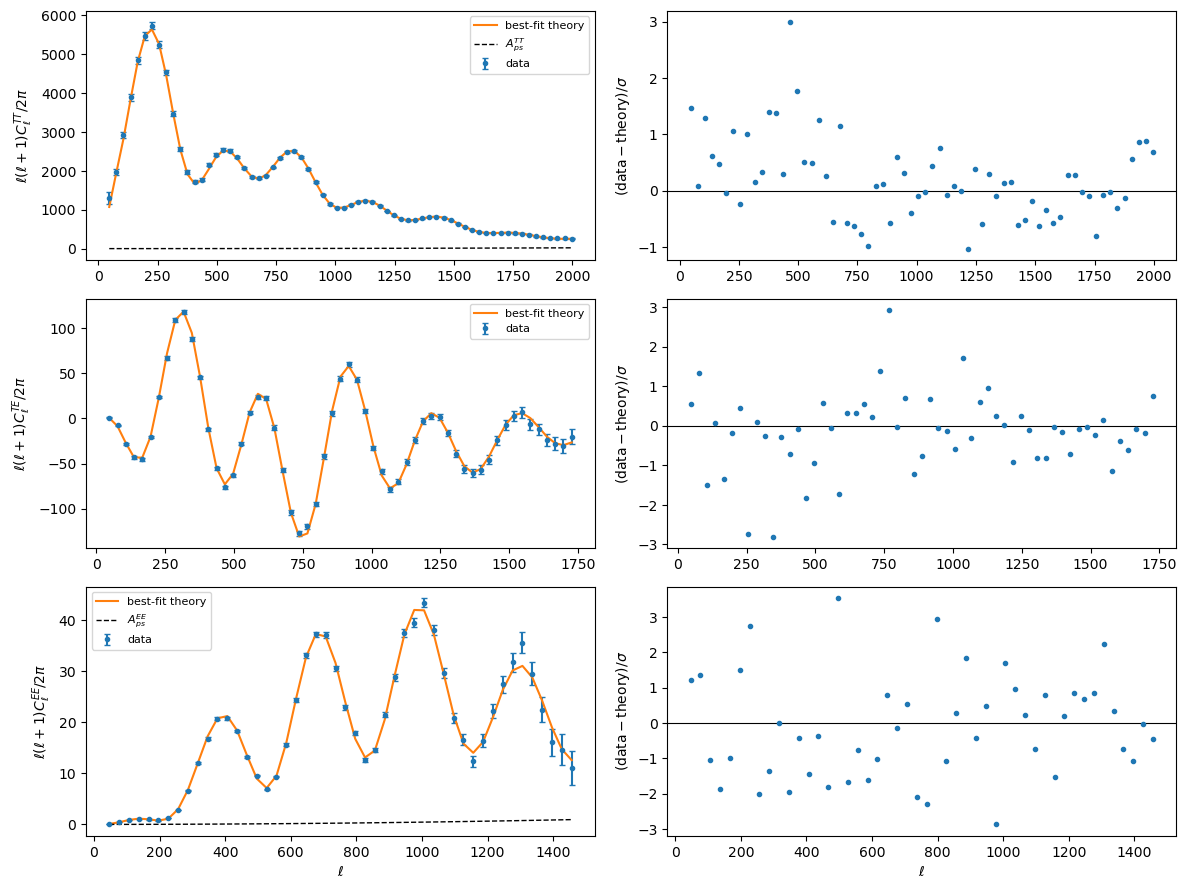

In [9]:
best_cosmo = {k: v for k, v in result["best_fit"].items() if k in FIDUCIAL}
best_cl = fitting.camb_cl(**best_cosmo, lmax=LMAX)
zero = np.zeros(LMAX + 1)
ps_tt = fitting.point_source_dl_template(LMAX, result["best_fit"]["A_ps_TT"])
ps_ee = fitting.point_source_dl_template(LMAX, result["best_fit"]["A_ps_EE"])

theory_tt = fitting.decouple_theory(workspace_tt, [best_cl["TT"] + ps_tt])[1:1 + n_tt]
theory_te = fitting.decouple_theory(workspace_te, [best_cl["TE"], zero])[1:1 + n_te]
theory_ee = fitting.decouple_theory(workspace_ee, [best_cl["EE"] + ps_ee, zero, zero, best_cl["BB"]])[1:1 + n_ee]
ps_tt_binned = fitting.decouple_theory(workspace_tt, [ps_tt])[1:1 + n_tt]
ps_ee_binned = fitting.decouple_theory(workspace_ee, [ps_ee, zero, zero, zero])[1:1 + n_ee]

theory_by_spec = {"TT": theory_tt, "TE": theory_te, "EE": theory_ee}
ps_by_spec = {"TT": ps_tt_binned, "EE": ps_ee_binned}

fig, axes = plt.subplots(3, 2, figsize=(12, 9))
for row, name in enumerate(["TT", "TE", "EE"]):
    ell = ells[name]
    ax_spec, ax_res = axes[row]

    dl_data = to_dl(ell, data_by_spec[name])
    dl_err = to_dl(ell, errors[error_slices[name]])
    dl_theory = to_dl(ell, theory_by_spec[name])

    ax_spec.errorbar(ell, dl_data, yerr=dl_err, fmt="o", ms=3, capsize=2, label="data")
    ax_spec.plot(ell, dl_theory, "-", label="best-fit theory")
    if name in ps_by_spec:
        ax_spec.plot(ell, to_dl(ell, ps_by_spec[name]), "k--", lw=1,
                     label=f"$A_{{ps}}^{{{name}}}$")
    ax_spec.set_ylabel(r"$\ell(\ell+1)C_\ell^{%s}/2\pi$" % name)
    ax_spec.legend(fontsize=8)

    residual = (data_by_spec[name] - theory_by_spec[name]) / errors[error_slices[name]]
    ax_res.axhline(0, color="k", lw=0.8)
    ax_res.plot(ell, residual, "o", ms=3)
    ax_res.set_ylabel(r"$(\mathrm{data-theory})/\sigma$")

axes[-1][0].set_xlabel(r"$\ell$")
axes[-1][1].set_xlabel(r"$\ell$")
plt.tight_layout()

## 5. Parameter constraints

Simple 2-parameter contour scan (Ωm-related: `omch2` vs `H0`) using iminuit's
built-in profile likelihood contour. For a full corner plot across all
parameters, loop over pairs and call `mncontour` for each, or export
`result["minuit"].covariance` to a corner-plot library.

In [ ]:
m = result["minuit"]
plt.figure(figsize=(5, 5))
m.draw_mncontour("H0", "omch2", cl=[1, 2])
plt.title(r"$1\sigma$/$2\sigma$ contours: $H_0$ vs $\Omega_c h^2$")
plt.tight_layout()